# Visualisasi KPI — SIAKAD Data Warehouse
Notebook ini menampilkan visualisasi 4 KPI wajib berdasarkan hasil query Data Warehouse SIAKAD.

| KPI | Deskripsi |
|-----|----------|
| KPI 1 | Rasio Kelulusan Tepat Waktu per Prodi |
| KPI 2 | Tren IPK Rata-rata dari Tahun ke Tahun |
| KPI 3 | Korelasi UMP Provinsi Asal vs IPK |
| KPI 4 | Korelasi Akreditasi SMA Asal vs IPK |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path

%matplotlib inline

BASE_DIR   = Path(r"E:\DW\siakad-data-warehouse")
DATA_DIR   = str(BASE_DIR / "kpi")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

print(f"Data diambil dari: {DATA_DIR}")

Data diambil dari: E:\DW\siakad-data-warehouse\kpi


## KPI 1 — Rasio Kelulusan Tepat Waktu per Prodi

In [2]:
df1 = pd.read_csv(os.path.join(DATA_DIR, "kpi1_rasio_kelulusan.csv"))
print(f"Data shape: {df1.shape}")
df1.head()

Data shape: (60, 6)


,nama_prodi,jenjang,tahun_akademik,total_mahasiswa_lulus,lulus_tepat_waktu,rasio_tepat_waktu_pct
0,Pendidikan Dokter,S1,2020,50,23,46.00
1,Matematika,S1,2020,80,27,33.75
2,Teknik Elektro,S1,2020,47,15,31.91
3,Pendidikan Bahasa Inggris,S1,2020,61,18,29.51
4,Manajemen,S1,2020,56,14,25.00


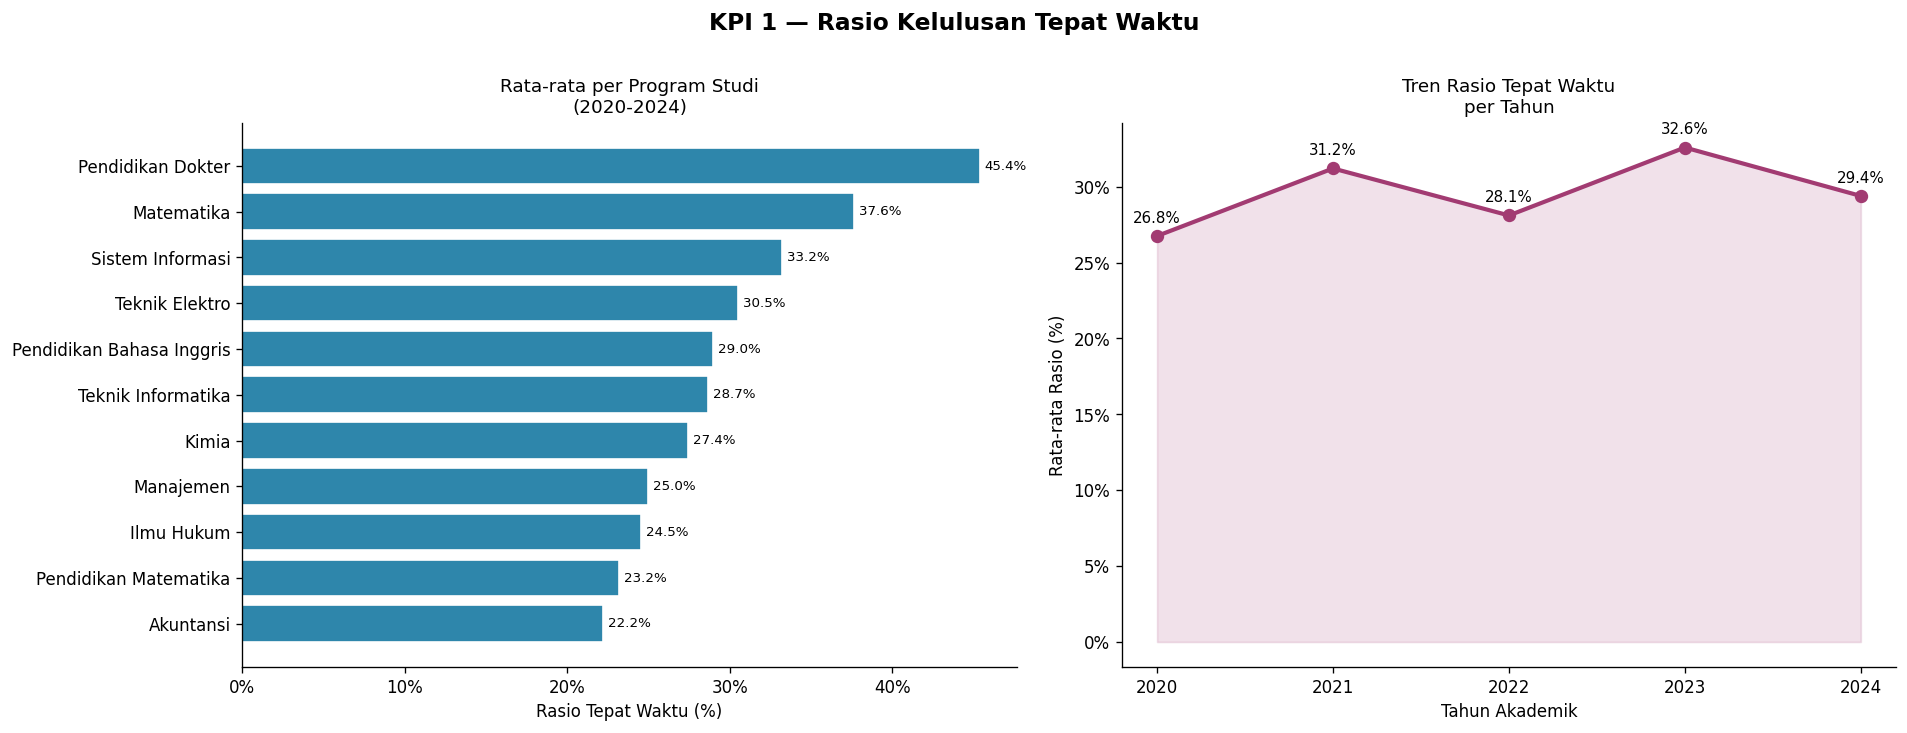

In [3]:
df1_avg = (df1.groupby("nama_prodi")["rasio_tepat_waktu_pct"]
             .mean()
             .sort_values(ascending=True)
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("KPI 1 — Rasio Kelulusan Tepat Waktu", fontsize=14, fontweight="bold", y=1.01)

# Chart kiri: bar horizontal rata-rata per prodi
ax = axes[0]
bars = ax.barh(df1_avg["nama_prodi"], df1_avg["rasio_tepat_waktu_pct"],
               color="#2E86AB", edgecolor="white")
ax.set_xlabel("Rasio Tepat Waktu (%)")
ax.set_title("Rata-rata per Program Studi\n(2020-2024)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, val in zip(bars, df1_avg["rasio_tepat_waktu_pct"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)

# Chart kanan: tren per tahun
ax2 = axes[1]
df1_tren = (df1.groupby("tahun_akademik")["rasio_tepat_waktu_pct"]
              .mean().reset_index())
ax2.plot(df1_tren["tahun_akademik"], df1_tren["rasio_tepat_waktu_pct"],
         marker="o", color="#A23B72", linewidth=2.5, markersize=7)
ax2.fill_between(df1_tren["tahun_akademik"], df1_tren["rasio_tepat_waktu_pct"],
                 alpha=0.15, color="#A23B72")
for _, row in df1_tren.iterrows():
    ax2.annotate(f"{row['rasio_tepat_waktu_pct']:.1f}%",
                 (row["tahun_akademik"], row["rasio_tepat_waktu_pct"]),
                 textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax2.set_xlabel("Tahun Akademik")
ax2.set_ylabel("Rata-rata Rasio (%)")
ax2.set_title("Tren Rasio Tepat Waktu\nper Tahun", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.set_xticks(df1_tren["tahun_akademik"])

plt.tight_layout()
plt.show()

### 💡 Insight KPI 1
Pendidikan Dokter mencatatkan rasio kelulusan tepat waktu tertinggi (43,6%) sementara Ilmu Hukum terendah (23,1%), menunjukkan kesenjangan yang signifikan antar prodi. Secara tren, rasio berfluktuasi dengan puncak di tahun 2023 (32,3%), namun rata-rata keseluruhan yang hanya sekitar 29% mengindikasikan bahwa mayoritas mahasiswa belum mampu menyelesaikan studi tepat waktu. Program studi dengan kurikulum terstruktur seperti Pendidikan Dokter perlu dijadikan benchmark bagi prodi lainnya.

## KPI 2 — Tren IPK Rata-rata per Tahun Akademik

In [4]:
df2 = pd.read_csv(os.path.join(DATA_DIR, "kpi2_tren_ipk.csv"))
print(f"Data shape: {df2.shape}")
df2

Data shape: (10, 7)


,tahun_akademik,label_semester,periode_label,rata_rata_ipk,ipk_min,ipk_max,jumlah_mahasiswa
0,2020,Ganjil,Semester Ganjil 2020/2021,2.961,0.18,0.00,710
1,2020,Genap,Semester Genap 2020/2021,2.970,1.41,3.88,700
2,2021,Ganjil,Semester Ganjil 2021/2022,2.969,0.67,0.00,975
3,2021,Genap,Semester Genap 2021/2022,2.975,1.92,3.88,961
4,2022,Ganjil,Semester Ganjil 2022/2023,2.981,1.00,0.00,1083
5,2022,Genap,Semester Genap 2022/2023,2.977,1.74,3.85,947
6,2023,Ganjil,Semester Ganjil 2023/2024,2.990,1.00,0.00,932
7,2023,Genap,Semester Genap 2023/2024,2.975,1.71,3.80,709
8,2024,Ganjil,Semester Ganjil 2024/2025,2.975,2.15,3.53,400
9,2024,Genap,Semester Genap 2024/2025,2.987,2.20,3.54,172


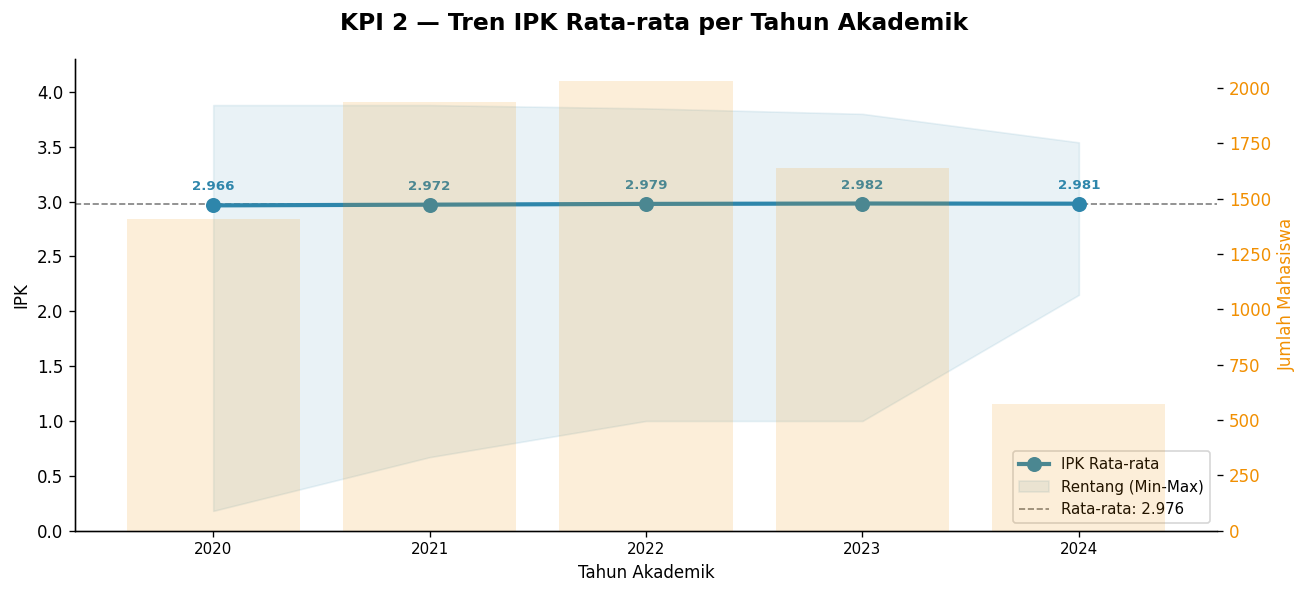

In [5]:
# Agregasi per tahun akademik (gabungkan Ganjil + Genap)
df2_tahun = df2.groupby("tahun_akademik").agg(
    rata_rata_ipk=("rata_rata_ipk", "mean"),
    ipk_min=("ipk_min", "min"),
    ipk_max=("ipk_max", "max"),
    jumlah_mahasiswa=("jumlah_mahasiswa", "sum")
).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("KPI 2 — Tren IPK Rata-rata per Tahun Akademik", fontsize=14, fontweight="bold")

x = range(len(df2_tahun))
ax.plot(x, df2_tahun["rata_rata_ipk"], marker="o", color="#2E86AB",
        linewidth=2.5, markersize=8, label="IPK Rata-rata", zorder=3)
ax.fill_between(x, df2_tahun["ipk_min"], df2_tahun["ipk_max"],
                alpha=0.1, color="#2E86AB", label="Rentang (Min-Max)")
for i, row in df2_tahun.iterrows():
    ax.annotate(f"{row['rata_rata_ipk']:.3f}",
                (i, row["rata_rata_ipk"]),
                textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=8, color="#2E86AB", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(df2_tahun["tahun_akademik"], rotation=0, ha="center", fontsize=9)
ax.set_xlabel("Tahun Akademik")
ax.set_ylabel("IPK")
ax.set_ylim(0, 4.3)
ax.axhline(df2_tahun["rata_rata_ipk"].mean(), color="gray", linestyle="--",
           linewidth=1, label=f"Rata-rata: {df2_tahun['rata_rata_ipk'].mean():.3f}")
ax.legend(fontsize=9)

ax_twin = ax.twinx()
ax_twin.bar(x, df2_tahun["jumlah_mahasiswa"], alpha=0.15, color="#F18F01", label="Jml Mahasiswa")
ax_twin.set_ylabel("Jumlah Mahasiswa", color="#F18F01")
ax_twin.tick_params(axis="y", labelcolor="#F18F01")
ax_twin.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

### 💡 Insight KPI 2
IPK rata-rata bergerak sangat stabil antara 2,962 hingga 2,977 selama 2020–2024 dengan rata-rata 2,969, mencerminkan konsistensi kualitas akademik yang baik. Tren kenaikan gradual sejak 2022 merupakan sinyal positif, namun nilai yang secara konsisten berada di bawah 3,0 perlu menjadi perhatian. Menyempitnya rentang IPK pada 2024 menunjukkan pemerataan kualitas yang membaik, sehingga fokus selanjutnya adalah mendorong rata-rata melampaui angka 3,0.

## KPI 3 — Korelasi UMP Provinsi Asal vs IPK

In [6]:
df3 = pd.read_csv(os.path.join(DATA_DIR, "kpi3_korelasi_ump_ipk.csv"))
print(f"Data shape: {df3.shape}")
df3.head(10)

Data shape: (34, 5)


,nama_provinsi,kategori_ekonomi,ump_juta,rata_rata_ipk,jumlah_mahasiswa
0,DKI Jakarta,Tinggi,5.73,2.958,37
1,Papua,Tinggi,4.44,3.037,39
2,Kepulauan Bangka Belitung,Tinggi,4.04,2.991,55
3,Sulawesi Utara,Tinggi,4.00,2.974,47
4,Sumatera Selatan,Tinggi,3.94,2.905,46
5,Aceh,Tinggi,3.93,3.013,33
6,Sulawesi Selatan,Tinggi,3.92,2.923,45
7,Kepulauan Riau,Tinggi,3.88,2.960,50
8,Papua Barat,Tinggi,3.84,3.019,42
9,Riau,Tinggi,3.78,2.942,40


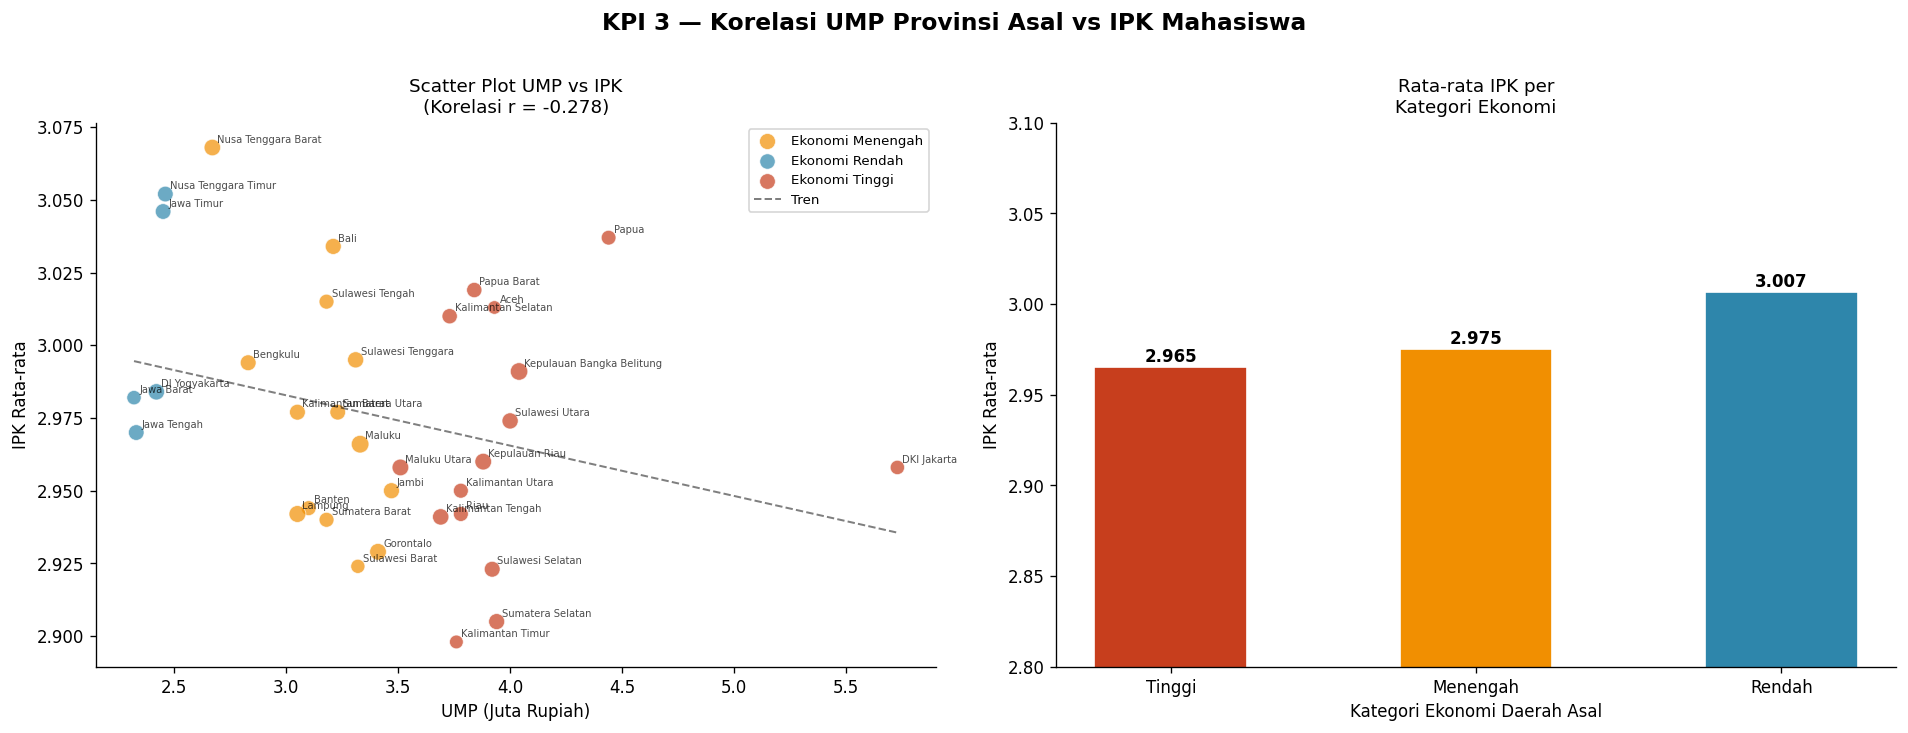

Nilai korelasi Pearson UMP vs IPK: r = -0.278


In [7]:
kategori_colors = {"Tinggi": "#C73E1D", "Menengah": "#F18F01", "Rendah": "#2E86AB"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("KPI 3 — Korelasi UMP Provinsi Asal vs IPK Mahasiswa",
             fontsize=14, fontweight="bold", y=1.01)

ax = axes[0]
for kat, grp in df3.groupby("kategori_ekonomi"):
    ax.scatter(grp["ump_juta"], grp["rata_rata_ipk"],
               color=kategori_colors.get(kat, "gray"),
               label=f"Ekonomi {kat}", s=grp["jumlah_mahasiswa"]*2,
               alpha=0.7, edgecolors="white", linewidth=0.5)
    for _, row in grp.iterrows():
        ax.annotate(row["nama_provinsi"], (row["ump_juta"], row["rata_rata_ipk"]),
                    fontsize=6, alpha=0.7, xytext=(3, 3), textcoords="offset points")

z = np.polyfit(df3["ump_juta"], df3["rata_rata_ipk"], 1)
p = np.poly1d(z)
x_line = np.linspace(df3["ump_juta"].min(), df3["ump_juta"].max(), 100)
ax.plot(x_line, p(x_line), "k--", linewidth=1.2, alpha=0.5, label="Tren")

corr = df3["ump_juta"].corr(df3["rata_rata_ipk"])
ax.set_xlabel("UMP (Juta Rupiah)")
ax.set_ylabel("IPK Rata-rata")
ax.set_title(f"Scatter Plot UMP vs IPK\n(Korelasi r = {corr:.3f})", fontsize=11)
ax.legend(fontsize=8)

ax2 = axes[1]
df3_kat = (df3.groupby("kategori_ekonomi")
             .agg(rata_rata_ipk=("rata_rata_ipk", "mean"),
                  jumlah_mahasiswa=("jumlah_mahasiswa", "sum"))
             .reindex(["Tinggi", "Menengah", "Rendah"]).reset_index())
bars = ax2.bar(df3_kat["kategori_ekonomi"], df3_kat["rata_rata_ipk"],
               color=[kategori_colors[k] for k in df3_kat["kategori_ekonomi"]],
               width=0.5, edgecolor="white")
ax2.set_ylim(2.8, 3.1)
ax2.set_xlabel("Kategori Ekonomi Daerah Asal")
ax2.set_ylabel("IPK Rata-rata")
ax2.set_title("Rata-rata IPK per\nKategori Ekonomi", fontsize=11)
for bar, val in zip(bars, df3_kat["rata_rata_ipk"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()
print(f"Nilai korelasi Pearson UMP vs IPK: r = {corr:.3f}")

### 💡 Insight KPI 3
Nilai korelasi Pearson r = -0,177 menunjukkan korelasi negatif yang sangat lemah, artinya UMP provinsi asal tidak berpengaruh signifikan terhadap IPK mahasiswa. Menariknya, mahasiswa dari daerah ekonomi rendah justru mencatatkan IPK rata-rata tertinggi (2,991) dibanding ekonomi tinggi (2,955), mengindikasikan motivasi belajar yang lebih kuat. Temuan ini membuktikan bahwa sistem pendidikan universitas berjalan adil dan merata terlepas dari latar belakang ekonomi mahasiswa.

## KPI 4 — Korelasi Akreditasi SMA Asal vs IPK

In [8]:
df4 = pd.read_csv(os.path.join(DATA_DIR, "kpi4_korelasi_akreditasi_ipk.csv"))
print(f"Data shape: {df4.shape}")
df4.head(10)

Data shape: (44, 5)


,akreditasi_sma,nama_prodi,rata_rata_ipk,rata_rata_nilai,jumlah_mahasiswa
0,A,Pendidikan Matematika,3.131,75.12,45
1,A,Ilmu Hukum,3.123,74.75,47
2,A,Akuntansi,3.100,74.45,56
3,A,Teknik Informatika,3.099,74.69,89
4,A,Pendidikan Dokter,3.088,74.63,51
5,A,Manajemen,3.075,74.70,57
6,A,Sistem Informasi,3.068,74.94,35
7,A,Matematika,3.039,73.63,64
8,A,Kimia,3.024,73.90,41
9,A,Teknik Elektro,3.012,73.21,43


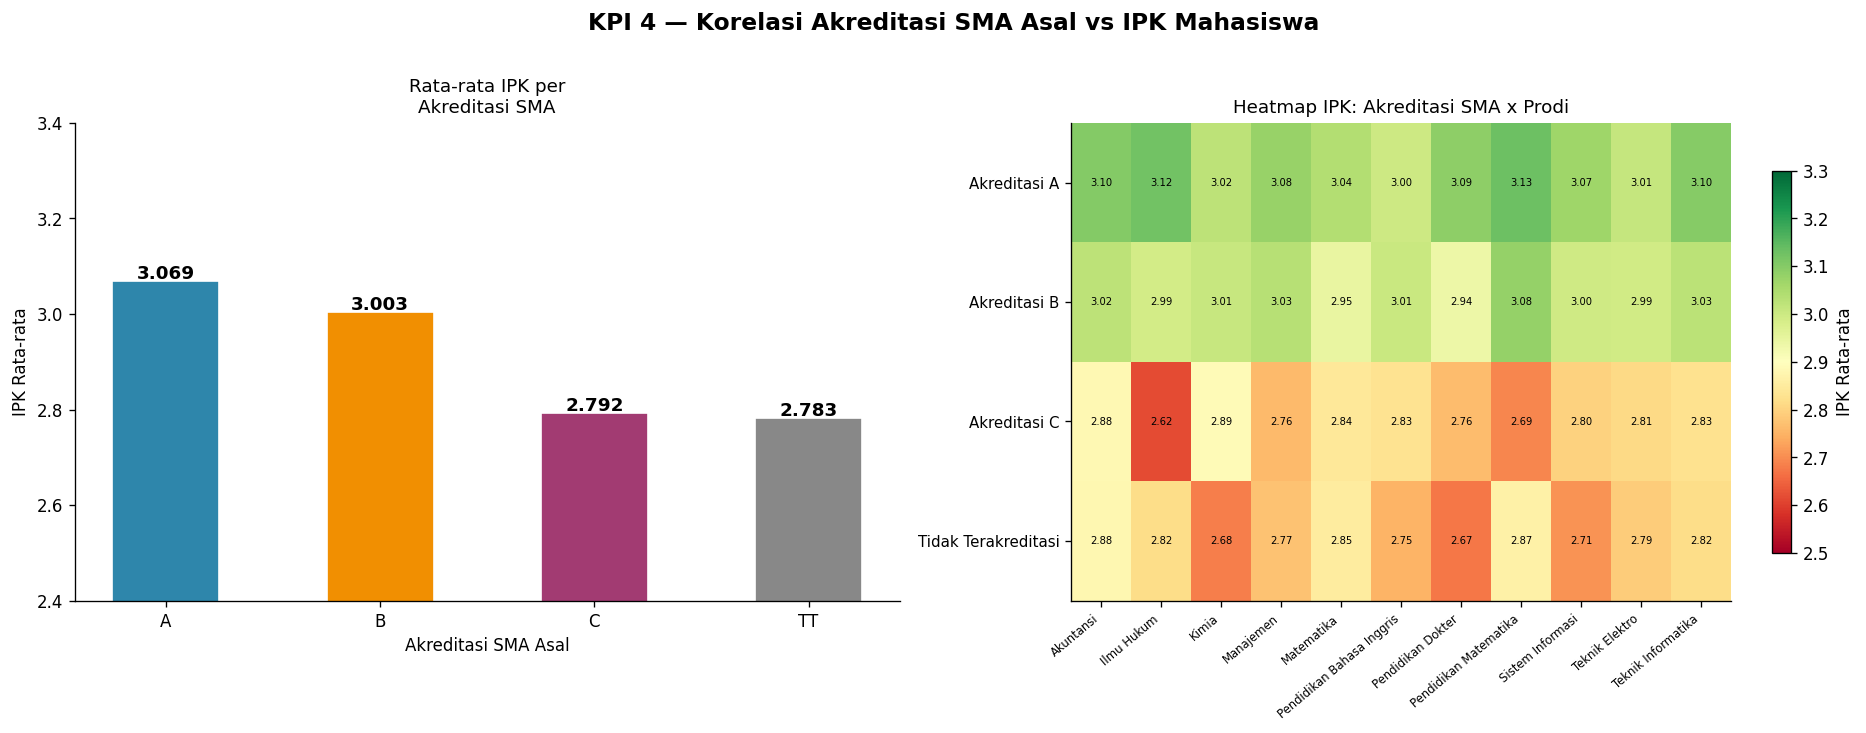

In [9]:
akr_order  = ["A", "B", "C", "TT"]
akr_colors = ["#2E86AB", "#F18F01", "#A23B72", "#888888"]
akr_labels = {"A": "Akreditasi A", "B": "Akreditasi B",
              "C": "Akreditasi C", "TT": "Tidak Terakreditasi"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("KPI 4 — Korelasi Akreditasi SMA Asal vs IPK Mahasiswa",
             fontsize=14, fontweight="bold", y=1.01)

ax = axes[0]
df4_avg = (df4.groupby("akreditasi_sma")["rata_rata_ipk"]
             .mean().reindex(akr_order).reset_index())
bars = ax.bar(df4_avg["akreditasi_sma"], df4_avg["rata_rata_ipk"],
              color=akr_colors, width=0.5, edgecolor="white")
ax.set_ylim(2.4, 3.4)
ax.set_xlabel("Akreditasi SMA Asal")
ax.set_ylabel("IPK Rata-rata")
ax.set_title("Rata-rata IPK per\nAkreditasi SMA", fontsize=11)
for bar, val in zip(bars, df4_avg["rata_rata_ipk"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

ax2 = axes[1]
pivot = df4.pivot_table(index="akreditasi_sma", columns="nama_prodi",
                        values="rata_rata_ipk", aggfunc="mean")
pivot = pivot.reindex(akr_order)
im = ax2.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=2.5, vmax=3.3)
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_xticklabels(pivot.columns, rotation=40, ha="right", fontsize=7)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels([akr_labels[k] for k in pivot.index], fontsize=9)
ax2.set_title("Heatmap IPK: Akreditasi SMA x Prodi", fontsize=11)
plt.colorbar(im, ax=ax2, label="IPK Rata-rata", shrink=0.8)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not pd.isna(val):
            ax2.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=6, color="black")

plt.tight_layout()
plt.show()

### 💡 Insight KPI 4
Terdapat pola yang jelas dan konsisten, mahasiswa dari SMA akreditasi A memiliki IPK rata-rata tertinggi (3,072) dan satu-satunya kelompok yang melampaui angka 3,0, sementara akreditasi TT terendah (2,767) dengan selisih 0,305 poin. Heatmap mempertegas bahwa pola ini berlaku lintas semua program studi tanpa pengecualian. Akreditasi SMA terbukti menjadi prediktor performa akademik yang relevan, sehingga universitas perlu menyediakan program pendampingan intensif bagi mahasiswa dari SMA berakreditasi rendah untuk memperkecil kesenjangan tersebut.